## How well do jobs and skills pay for Data Analysts in Europe?
#### Methodology
1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Analysts
3. Visualize for highest paying skills and most demanded skills

### Import Libraries and Data

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

### Compare Median Salaries Across Data Roles

Due to limited data availability in France, I expand the analysis to include several major European countries (United Kingdom, Germany, France, Poland, Spain, Portugal, and the Netherlands).  

This broader scope provides a more robust dataset for salary analysis while still reflecting similar job market dynamics across Europe.  

All salaries are expressed in USD, which ensures consistency and allows for direct comparison across countries. However, results should still be interpreted with caution, as salary levels and cost of living may vary between countries.

In [42]:
# Filter dataset to include selected European countries and valid salary data
countries = ['United Kingdom', 'Germany', 'France', 'Poland', 'Spain', 'Portugal', 'Netherlands']

df_EU = df[(df['job_country'].isin(countries))].dropna(subset=['salary_year_avg'])

To ensure robust and meaningful insights, I focus on the most common data roles across the European dataset.  

In [43]:
# Select the most common data roles in Europe and prepare them for salary comparison
job_titles = df_EU['job_title_short'].value_counts().index[:6].tolist()

df_EU_top6 = df_EU[df_EU['job_title_short'].isin(job_titles)]

# Order roles by median salary
job_order = df_EU_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

job_titles

['Data Analyst',
 'Data Engineer',
 'Data Scientist',
 'Machine Learning Engineer',
 'Senior Data Engineer',
 'Senior Data Scientist']

### Analyze Salary Distributions Across Data Roles

To better understand compensation differences in the Europe data job market, I visualize the salary distribution for the most common roles.  

This allows me to compare salary ranges, identify variability, and highlight differences between job titles.

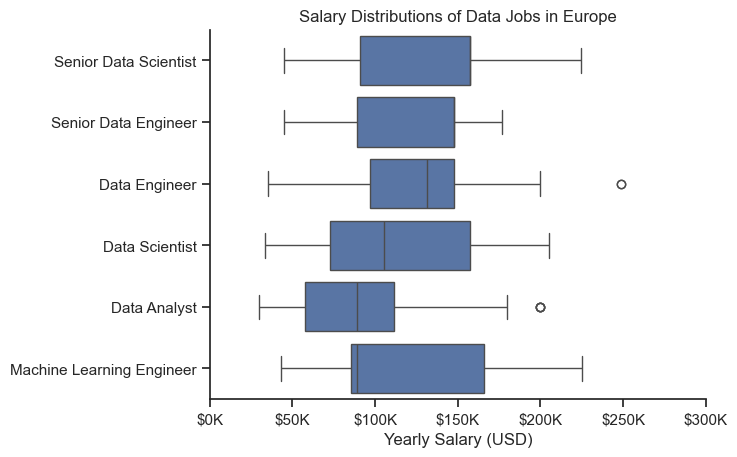

In [44]:
# Visualize salary distributions across top data roles in Europe
sns.boxplot(
    data=df_EU_top6,
    x='salary_year_avg',
    y='job_title_short',
    order=job_order
)

sns.set_theme(style='ticks')
sns.despine()

plt.title('Salary Distributions of Data Jobs in Europe')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')

plt.xlim(0, 300000)  # plus réaliste pour Europe

# Format axis in K$
from matplotlib.ticker import FuncFormatter
ticks_x = FuncFormatter(lambda x, pos: f'${int(x/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)

plt.show()

### Investigate Salary by Skill for Data Analysts

I analyze how specific skills influence salaries for Data Analysts across Europe.  


In [ ]:
# Prepare Data Analyst dataset (Europe) to analyze salary differences by skill
df_DA_EU = df[
    (df['job_title_short'] == 'Data Analyst') & 
    (df['job_country'].isin(countries))
].dropna(subset=['salary_year_avg']).copy()

# Split skills into individual rows to analyze salary per skill
df_DA_EU = df_DA_EU.explode('job_skills')

df_DA_EU[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
1490,43200.0,gdpr
1490,43200.0,sap
1490,43200.0,powerpoint
1490,43200.0,excel
1555,111175.0,databricks


### Identify the Highest-Paying Skills for Data Analysts

I analyze the median salary associated with each skill for Data Analysts across Europe to identify the most valuable skills in terms of compensation.  



In [ ]:
df_DA_top_pay = df_DA_EU.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']) \
    .sort_values(by='median', ascending=False)

df_DA_top_pay = df_DA_top_pay.head(10)

df_DA_top_pay

,count,median
job_skills,,
tensorflow,1,177283.00
pytorch,1,177283.00
terraform,2,165100.75
aurora,1,165000.00
mongo,1,165000.00
postgresql,1,165000.00
mongodb,2,165000.00
nosql,6,164391.00
shell,1,156500.00


To better balance salary and demand, I look at both how often each skill appears and its associated median salary for Data Analysts in Europe. 

In [48]:
df_DA_skills = df_DA_EU.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']) \
    .sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)

df_DA_skills

,count,median
job_skills,,
looker,33,111175.00
spark,28,111175.00
tableau,77,100500.00
sql,154,98500.00
python,116,98500.00
r,39,89204.00
power bi,39,89100.00
azure,24,89100.00
excel,80,76308.75


### Compare High-Paying and In-Demand Skills

I compare the highest-paying skills with the most in-demand ones for Data Analysts across Europe.  

This highlights which skills are both financially rewarding and widely востребed, helping identify the most valuable skills in the job market.

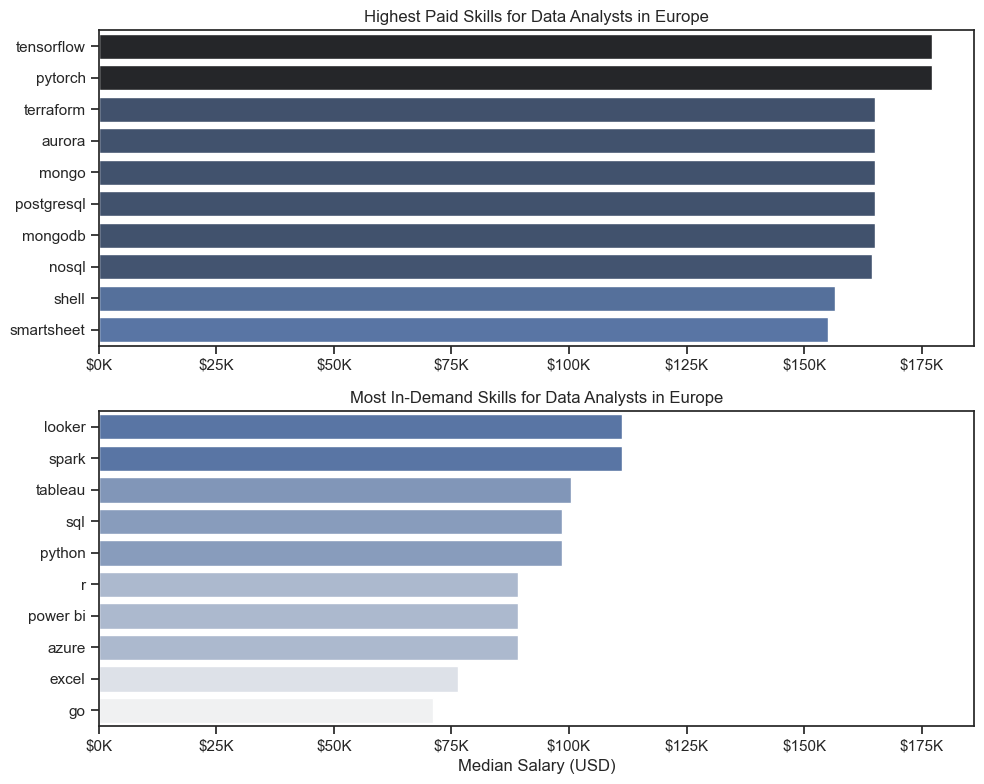

In [50]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Top 10 Highest Paid Skills
sns.barplot(
    data=df_DA_top_pay,
    x='median',
    y=df_DA_top_pay.index,
    hue='median',
    ax=ax[0],
    palette='dark:b_r'
)
ax[0].legend().remove()
ax[0].set_title('Highest Paid Skills for Data Analysts in Europe')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# Top 10 Most In-Demand Skills
sns.barplot(
    data=df_DA_skills,
    x='median',
    y=df_DA_skills.index,
    hue='median',
    ax=ax[1],
    palette='light:b'
)
ax[1].legend().remove()
ax[1].set_title('Most In-Demand Skills for Data Analysts in Europe')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

sns.set_theme(style='ticks')
plt.tight_layout()
plt.show()